# 03 · Evaluación del modelo — Argly
Métricas sobre el **test held-out** (variantes de patrón no vistas en train).

In [1]:
import sys, pathlib
p = pathlib.Path.cwd()
while not (p / 'src').exists() and p != p.parent:
    p = p.parent
sys.path.insert(0, str(p))

In [2]:
from src.ingestion.generate_synthetic import generar
from src.pipeline import evaluar_metricas
dfs = generar(seed=42)
evaluar_metricas(dfs)

{'n_test': 444,
 'auc_reglas': 0.829,
 'auc_hibrido': 0.924,
 'auc_ml': 0.954,
 'precision': 0.969,
 'recall': 0.802,
 'f1': 0.877}

**Lectura:** el AUC híbrido supera al de solo-reglas y el ML no degrada el ranking. Precisión alta = pocas falsas alarmas para el analista.

## Matriz de confusión (alerta = amarillo o rojo)

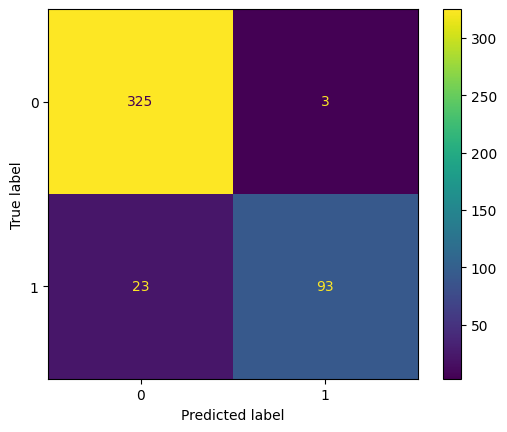

In [3]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from src.features.build_features import construir_features
from src.models.ml_model import entrenar
from src.anomaly.detector import detectar
from src.scoring.score import puntuar_features
F = construir_features(dfs)
_, prob = entrenar(F); anom = detectar(F)
P = puntuar_features(F, prob, anom)
test = (F['split'] == 'test').values
y = F['etiqueta_fraude_simulada'].astype(int).values[test]
pred = (P['score'].values[test] >= 41).astype(int)
ConfusionMatrixDisplay(confusion_matrix(y, pred)).plot(); None